In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dill
import warnings
warnings.filterwarnings("ignore")

In [2]:
# !jupyter nbconvert --to script load_vtem_estancia_all.ipynb

In [3]:
import json
with open("../vtem_et_silver_city.json", "r") as file:
    vtem_et_dict = json.load(file)

In [4]:
times_orig = np.array(vtem_et_dict['times'])
currents = np.array(vtem_et_dict['currents'])
current_times = np.array(vtem_et_dict['current_times'])

In [5]:
# number = '08'
survey_name = f'GL250193_NewMexicoTech_Gila-Animas_VTEM_ET_Final'

In [6]:
df_data = pd.read_csv(f"../../Silver_city/GL250193_finals/Database/{survey_name}.csv")
df_data = df_data[~np.isnan(df_data['x'])]

In [7]:
xy = df_data[['x', 'y']].values
mag = df_data['mag2'].values
vmin = np.percentile(mag, 5)
vmax = np.percentile(mag, 95)

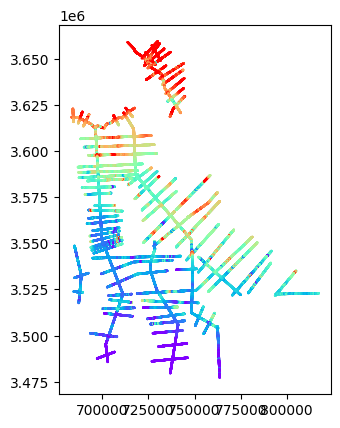

In [8]:
out = plt.scatter(
    xy[::10,0], xy[::10,1], c=mag[::10], s=0.5, vmin=vmin, vmax=vmax,
    cmap='rainbow'
)
plt.gca().set_aspect(1)

In [9]:
# x, y, values_mag_idw = inverse_distance_interpolation(
#     xy[::10,:], mag[::10], dx=100, dy=100, k_nearest_points=50,
#     # x_pad=500, y_pad=500,
#     max_distance=2000.,
# )

In [10]:
# fig, ax = plt.subplots(1,1, figsize=(10, 6))
# out = plt.pcolormesh(x, y, values_mag_idw, vmin=vmin, vmax=vmax,
#     cmap='rainbow'
# )
# # ax.plot(topography[:,0], topography[:,1], 'k,', alpha=0.1)
# ax.set_xlabel("Easting (m)")
# ax.set_ylabel("Northing (m)")
# cb = plt.colorbar(out)
# cb.set_label('Total magnetic intensity (nT)')
# ax.grid(True, alpha=0.5)
# ax.set_aspect(1)
# fig.autofmt_xdate()

In [11]:
i_start = 3
i_end = 53
data_header = np.array([f'SFz[{ii}]' for ii in range(5, 58)])[i_start:i_end]
data_header = data_header.tolist()
times = times_orig[i_start:i_end]

In [12]:
data = df_data[data_header].values

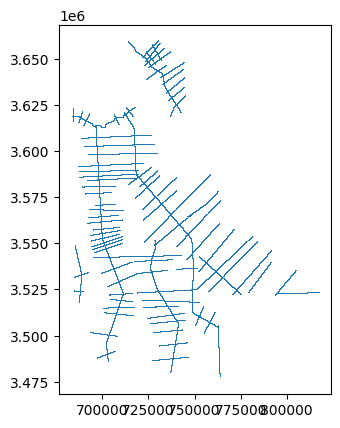

In [13]:
xy = df_data[['x', 'y']].values
plt.plot(xy[:,0], xy[:,1], ',')
plt.gca().set_aspect(1)

In [14]:
uniq_lines = np.unique(df_data['Line'].values)

In [15]:
df_data.shape[0] / 200

3966.425

# Stacking raw AEM data over about 30-40 m interval (i.e. binning)

In [16]:
import pandas as pd
dx = 40.
values = []
values_std = []
for i_line, line in enumerate(uniq_lines):
    df_line = df_data[df_data['Line']==line]
    
    df_line = df_line.copy()

    xy = df_line[['x', 'y']].values
    distance = np.sqrt(((xy - xy[0,:])**2).sum(axis=1))
    n_sounding = np.round(distance.max() / dx) + 1
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)

    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
               [['distance','x','y','DEM','radar','radarb','PLM'] + data_header]
               .mean()
    )
    binned.insert(0, 'line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
               [['DEM','radar','radarb'] + data_header]
               .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance','x','y','DEM','radar','radarb','PLM'] + data_header)
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['DEM','radar','radarb'] + data_header)

# TODOs
- Expand the binning in a way that can handle a larger swath for the later time gates, so do it by channel [done]
- Make sure the bin interval is about 40 m while the swath could be much bigger hundres of meters 
- There are relatively large errors on early time gates due to flight height change ... how to handle?
    - problem 1: accuracy issue of the code
    - problem 2: hard to fit the data
- May be remove data greater than XX me height

In [17]:
from sklearn.preprocessing import MinMaxScaler
# Create scaler
from ipywidgets import widgets, interact

In [18]:
def foo(line):
    fig, axs = plt.subplots(2,1, figsize=(20, 10))
    ax0, ax = axs

    # line = uniq_lines[i_line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    ax0.plot(df_data_binned['x'], df_data_binned['y'], ',')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], color='k', lw=1)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax_1.legend()
interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L1000', 'L1020', 'L1030', 'L1040', 'L1050', 'L1060'…

<function __main__.foo(line)>

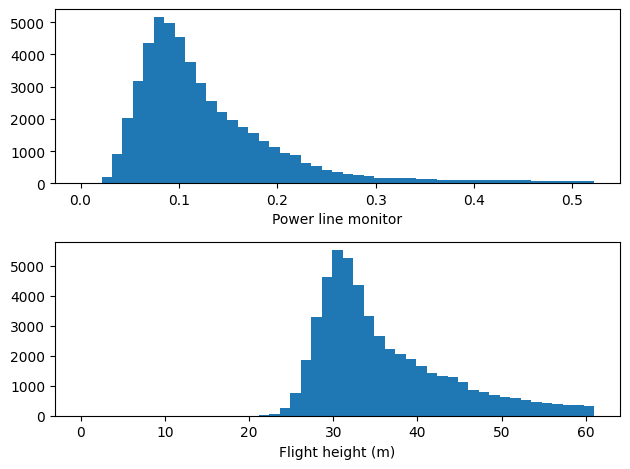

In [19]:
fig, axs = plt.subplots(2,1)
ax1, ax2 = axs
out = ax1.hist(df_data_binned['PLM'], bins=np.linspace(0, np.percentile(df_data_binned['PLM'], 95)))
out = ax2.hist(df_data_binned['radarb'], bins=np.linspace(0, np.percentile(df_data_binned['radarb'], 95)))
ax1.set_xlabel("Power line monitor")
ax2.set_xlabel("Flight height (m)")
plt.tight_layout()

In [20]:
data = df_data_binned[data_header].values.astype(float)
data_rerr = (df_data_std_binned[data_header].values / abs(df_data_binned[data_header].values)).astype(float)
channel_index = np.tile(np.arange(data.shape[1]), (data.shape[0], 1))
line_index = np.tile(df_data_binned['Line'].values, (data.shape[1], 1)).T
height_index = np.tile(df_data_binned['radarb'].values, (data.shape[1], 1)).T
plm_index = np.tile(df_data_binned['PLM'].values, (data.shape[1], 1)).T
noise_level = 0.015 #0.015 pV/A/m4
ind_omit = np.logical_and(data_rerr>0.05, channel_index>=0) | (data<noise_level)
ind_large_error = np.logical_or(plm_index>0.5, height_index>60)
# ind_omit = np.logical_and(data_rerr>0.05, channel_index>=0)
# ind_omit_line = np.logical_and(data_rerr>0.01, channel_index>=0) & (line_index =='L100')
data_rerr[ind_large_error] = abs(data[ind_large_error]) * 0.3
data[ind_omit] = np.nan
data_rerr[ind_omit] = np.nan

In [21]:
other_values = df_data_binned[['Line', 'distance','x','y','DEM','radar','radarb','PLM']].values
df_data_binned_filtered = pd.DataFrame(data=np.hstack((other_values, data)), columns=['Line', 'distance','x','y','DEM','radar','radarb','PLM'] + data_header)

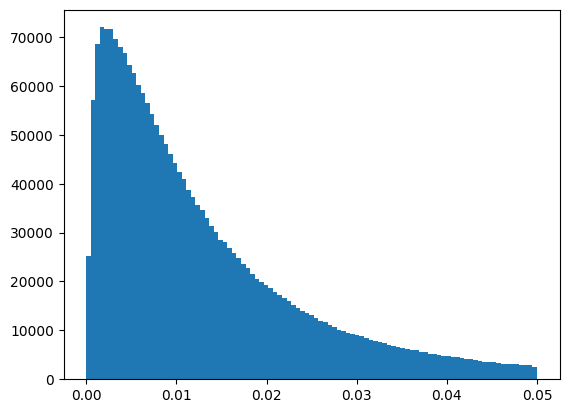

In [22]:
out = plt.hist(data_rerr[~ind_omit], bins=np.linspace(0., 0.05, 100))

In [23]:
df_data_binned_line_filtered = df_data_binned_filtered[df_data_binned_filtered['Line']==line]

In [24]:
def foo(line):
    fig, axs = plt.subplots(3,1, figsize=(20, 15))
    ax0, ax, ax1 = axs

    # line = uniq_lines[i_line]
    df_data_binned_line_filtered = df_data_binned_filtered[df_data_binned_filtered['Line']==line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    ax0.plot(df_data_binned_filtered['x'], df_data_binned_filtered['y'], ',')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], color='k', lw=1)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax_1.legend()
    
    ax1_1 = ax1.twinx()
    ax1.semilogy(df_data_binned_line['distance'], df_data_binned_line_filtered[data_header], color='k', lw=1)
    ax1_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax1_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax1_1.legend()
    vmax = df_data_binned_line[data_header].values.max()
    vmin = noise_level
    ax.set_ylim(vmin, vmax)
    ax1.set_ylim(vmin, vmax)
interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L1000', 'L1020', 'L1030', 'L1040', 'L1050', 'L1060'…

<function __main__.foo(line)>

In [25]:
from ipywidgets import interact, widgets

Text(0.5, 1.0, 'Flight height')

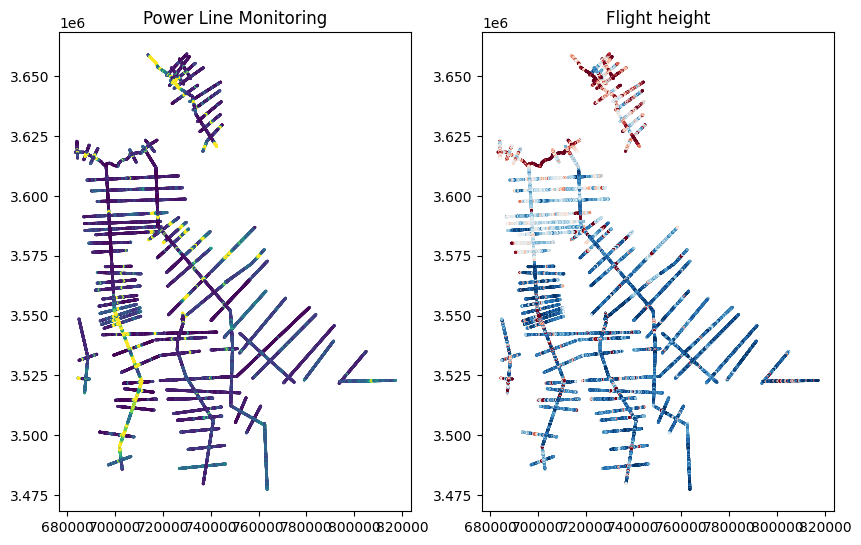

In [26]:
fig, axs = plt.subplots(1,2, figsize=(10, 10))
ax1, ax2 = axs
ax1.scatter(
    df_data_binned['x'], df_data_binned['y'], c=df_data_binned['PLM'], 
    s=1,
    vmin=np.percentile(df_data_binned['PLM'], 5),
    vmax=np.percentile(df_data_binned['PLM'], 95)
)
ax1.set_aspect(1)

ax2.scatter(
    df_data_binned['x'], df_data_binned['y'], c=df_data_binned['radarb'], 
    s=1,
    vmin=np.percentile(df_data_binned['radarb'], 5),
    vmax=np.percentile(df_data_binned['radarb'], 95),
    cmap='RdBu_r'
)
ax2.set_aspect(1)
ax1.set_title("Power Line Monitoring")
ax2.set_title("Flight height")

In [27]:
# i_sounding = 0
def foo(i_sounding):
    plt.errorbar(times, data[i_sounding,:], yerr=data_rerr[i_sounding,:])
    plt.yscale('log')
    plt.xscale('log')
    # plt.title(f"{binned['distance'].values[i_sounding]:.1f}")
interact(foo, i_sounding = widgets.IntSlider(min=0, max=data.shape[0]-1, continous_update=False, step=5))    

interactive(children=(IntSlider(value=0, description='i_sounding', max=54031, step=5), Output()), _dom_classes…

<function __main__.foo(i_sounding)>

In [28]:
source_area_orig = 459.32
dobs = -df_data_binned[data_header].values.flatten() * 1e-12
tmp_std = df_data_std_binned[data_header].values.flatten() * 1e-12
dobs_std = abs(dobs) * 0.03
dobs_std[tmp_std > abs(dobs) * 0.03]=tmp_std[tmp_std > abs(dobs) * 0.03]
dobs_std[ind_omit.flatten()] = np.inf
dobs_std[ind_large_error.flatten()] = abs(dobs)[ind_large_error.flatten()] * 0.3
noise_floor = noise_level * 1e-12
dobs_std += noise_floor

In [29]:
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
topography = df_data_binned[['x','y', 'DEM']].values
source_heights = df_data_binned['radarb'].values
thickness = get_vertical_discretization(39, 3, 1.07)

>> Depth from the surface to the base of the bottom layer is 556.9m


In [30]:
from simpeg import maps
import simpeg.electromagnetics.time_domain as tdem
from pymatsolver import PardisoSolver
import simpeg
from types import SimpleNamespace

In [31]:
input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "time_input_currents":current_times,
    "input_currents":currents,
    "times":times,    
    "data":dobs,
    "data_std":dobs_std,
    "survey_name":survey_name
}
inp = SimpleNamespace(**input_data_dict)

In [32]:
# !python run_inversion.py

In [33]:
input_data_dict
dill.dump(input_data_dict, open("./input_data_bootheel.pik", "wb"))

In [34]:
radius = np.sqrt(1/np.pi)

In [35]:
# !mkdir inversion_results_GL250194_F1
# get_ipython().system(f'mkdir inversion_results_{survey_name}')

In [36]:
source_locations = np.c_[inp.topography[:,0], inp.topography[:,1], inp.topography[:,2]+inp.source_heights]
receiver_locations = np.c_[inp.topography[:,0], inp.topography[:,1],  inp.topography[:,2]+inp.source_heights]
n_sounding = source_locations.shape[0]

source_list = []
receiver_orientation = 'z'
source_orientation = 'z'
for i_sounding in range(n_sounding):    
    waveform = tdem.sources.PiecewiseLinearWaveform(inp.time_input_currents, inp.input_currents)
    source_location = source_locations[i_sounding, :]
    receiver_location = receiver_locations[i_sounding, :]

    # Receiver list

    dbzdt_receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
            receiver_location, inp.times, "z",
    )

    # Make a list containing all receivers even if just one

    # Must define the transmitter properties and associated receivers

    source_list.append(tdem.sources.CircularLoop(
        [dbzdt_receiver],
        location=source_location,
        waveform=waveform,
        radius=radius,
        i_sounding=i_sounding,
    )
    )

survey = tdem.Survey(source_list)
hz = np.r_[inp.thickness, inp.thickness[-1]]

n_layer = len(hz)
nP = n_sounding * n_layer
sigma_map = maps.ExpMap(nP=nP)

simulation = tdem.Simulation1DLayeredStitched(
    survey=survey, 
    thicknesses=inp.thickness, 
    sigmaMap=sigma_map,
    topo=inp.topography, 
    parallel=True, 
    n_cpu=8, 
    verbose=False, 
    solver=PardisoSolver,
)

n_time = inp.times.size

# Create data ojbect
data_object = simpeg.data.Data(survey, dobs=dobs, standard_deviation=inp.data_std)
dmis = simpeg.data_misfit.L2DataMisfit(simulation=simulation, data=data_object)
inds_active_dobs = dobs==9999
print (f"Percentage of the active data = {inds_active_dobs.sum()}/{len(dobs)}={inds_active_dobs.sum()/len(dobs)*100:.0f}%")

from simpeg.electromagnetics.utils.em1d_utils import set_mesh_1d
import scipy
from discretize import SimplexMesh
from simpeg.regularization.laterally_constrained import LaterallyConstrained

tri = scipy.spatial.Delaunay(inp.topography[:,:2])
mesh_radial = SimplexMesh(tri.points, tri.simplices)
mesh_vertical = set_mesh_1d(hz)
mesh_reg = [mesh_radial, mesh_vertical]

def get_active_edge_indices_with_distance(mesh_radial, mesh_vertical, maximum_distance=1000):
    nz = mesh_vertical.n_cells
    edge_lengths = mesh_radial.edge_lengths
    inds = edge_lengths < maximum_distance
    indActiveEdges = np.tile(inds.reshape([-1,1]), nz).flatten()
    return inds, indActiveEdges

inds, indActiveEdges = get_active_edge_indices_with_distance(
    mesh_radial, mesh_vertical, maximum_distance=500.
)

reg = LaterallyConstrained(
    mesh_reg, 
    mapping=simpeg.maps.IdentityMap(nP=nP),
    alpha_s = 0.,
    alpha_r = 1.,
    alpha_z = 1./2.,
    active_edges=indActiveEdges
)

opt = simpeg.optimization.ProjectedGNCG(maxIter=15, maxIterCG=50)
invProb = simpeg.inverse_problem.BaseInvProblem(dmis, reg, opt)
beta = simpeg.directives.BetaSchedule(coolingFactor=2, coolingRate=1)
betaest = simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1.)
target = simpeg.directives.TargetMisfit(chifact=1)
precond = simpeg.directives.UpdatePreconditioner()
save_model_dict = simpeg.directives.SaveOutputDictEveryIteration()
save_model = simpeg.directives.SaveModelEveryIteration()
save_model_dict.outDict = {}

inv = simpeg.inversion.BaseInversion(
    invProb, 
    directiveList=[
        betaest, 
        beta, 
        precond,
        target, 
        save_model_dict
    ]
)
invProb.counter = opt.counter = simpeg.utils.Counter()
opt.LSshorten = 0.5
opt.remember('xc')
m0 = np.ones(nP) * np.log(1./10.)
# mest = inv.run(m0)

# import dill
# survey_name = 'GL250194_F01'
# dill.dump(save_model_dict.outDict, open(f"./inversion_results_{survey_name}.pik", "wb"))


Percentage of the active data = 0/2701600=0%


In [37]:
import dill
# dill.dump(save_model_dict.outDict, open(f"./inversion_results_{survey_name}.pik", "wb"))
outDict = dill.load(open(f"./second_path_results/inversion_results_smooth_0.0e+00_10_10.pik", "rb"))
outDict_ref1 = dill.load(open(f"./second_path_results/inversion_results_smooth_1.0e-01_10_30.pik", "rb"))
outDict_ref2 = dill.load(open(f"./second_path_results/inversion_results_smooth_1.0e-01_10_10.pik", "rb"))
outDict_sharp = dill.load(open(f"./second_path_results/inversion_results_sharp_comp_1.0_1.0.pik", "rb"))

In [38]:
n_time = len(times)
n_sounding = inp.topography.shape[0]

In [39]:
iteration = len(outDict.keys())
iteration = 16
m = outDict[iteration]['m']

dpred = outDict[iteration]['dpred']
DPRED = dpred.reshape((n_sounding, n_time))
DOBS = dobs.reshape((n_sounding, n_time))
# DOBS[ind_omit] = np.nan
# STD = data_object.standard_deviation.reshape((n_sounding, n_time))

iterations = list(outDict.keys())
phi_d = []
phi_m = []
for ii in iterations:
    phi_d.append(outDict[ii]['phi_d'])
    phi_m.append(outDict[ii]['phi_m'])

In [40]:
phi_d[iteration]

1016245.2652737552

In [41]:
(n_sounding*n_time)

2701600

In [42]:
iteration_ref1 = len(outDict_ref1.keys())
iteration_ref2 = len(outDict_ref2.keys())
m_ref1 = outDict_ref1[iteration_ref1]['m']
m_ref2 = outDict_ref2[iteration_ref2]['m']

rho_smooth = 1./np.exp(m)
rho_ref1 = 1./np.exp(m_ref1)
rho_ref2 = 1./np.exp(m_ref2)

phi_d_ref1 = []
phi_m_ref1 = []
for ii in list(outDict_ref1.keys()):
    phi_d_ref1.append(outDict_ref1[ii]['phi_d'])
    phi_m_ref1.append(outDict_ref1[ii]['phi_m'])
    
phi_d_ref2 = []
phi_m_ref2 = []
for ii in list(outDict_ref2.keys()):
    phi_d_ref2.append(outDict_ref2[ii]['phi_d'])
    phi_m_ref2.append(outDict_ref2[ii]['phi_m'])    

iteration_sharp = len(outDict_sharp.keys())
iteration_sharp = 40
m_sharp = outDict_sharp[iteration_sharp]['m']
rho_sharp = 1./np.exp(m_sharp)

Text(0, 0.5, 'Data misfit')

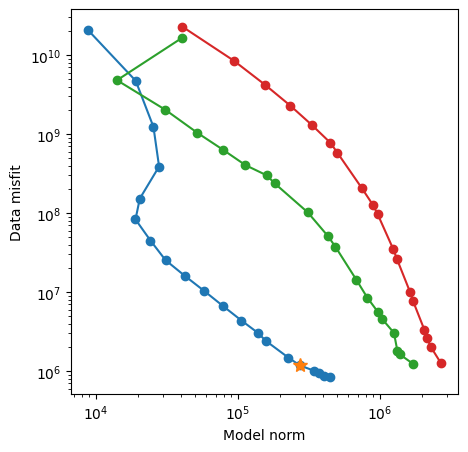

In [43]:
ii = iteration-1
fig = plt.figure(figsize=(5,5))
plt.loglog(phi_m, phi_d, 'o-')
plt.loglog(phi_m[ii], phi_d[ii], '*', ms=10)

plt.loglog(phi_m_ref1, phi_d_ref1, 'o-')
plt.loglog(phi_m_ref2, phi_d_ref2, 'o-')

plt.xlabel("Model norm")
plt.ylabel("Data misfit")


In [44]:
other_values = df_data_binned[['Line', 'distance','x','y','DEM','radar','radarb','PLM']].values
df_data_binned_pred = pd.DataFrame(data=np.hstack((other_values, -DPRED * 1e12)), columns=['Line', 'distance','x','y','DEM','radar','radarb','PLM'] + data_header)


In [45]:
# i_sounding = 0
def foo(i_sounding):
    plt.plot(times, -DOBS[i_sounding,:], '.')
    plt.plot(times, -DPRED[i_sounding,:])
    plt.yscale('log')
    plt.xscale('log')
    # plt.title(f"{binned['x'].values[i_sounding]:.1f}")
interact(foo, i_sounding = widgets.IntSlider(min=0, max=n_sounding-1, continous_update=False, step=5))    


interactive(children=(IntSlider(value=0, description='i_sounding', max=54031, step=5), Output()), _dom_classes…

<function __main__.foo(i_sounding)>

In [46]:
from simpeg.electromagnetics.utils.em1d_utils import Stitched1DModel

In [47]:
line = np.array([int(val.strip('L').strip('T')) for val in df_data_binned['Line'].values])

In [48]:
model = Stitched1DModel(
    topography=inp.topography,
    physical_property=1./np.exp(m),
    line=line,
    time_stamp=np.arange(n_sounding),
    thicknesses=thickness,    
)

30.32408650331168

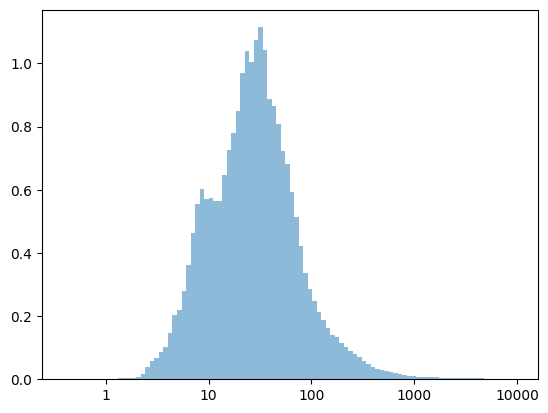

In [49]:
out = plt.hist(np.log10(1./np.exp(m)), bins=100, density=True, alpha=0.5)
# out1 = plt.hist(np.log10(1./np.exp(m_ref1)), bins=out[1], density=True, alpha=0.5)
# out2 = plt.hist(np.log10(1./np.exp(m_ref2)), bins=out[1], density=True, alpha=0.5)
xticks,_ = plt.xticks()
ax = plt.gca()
ax.set_xticklabels([f"{10**x:.0f}"for x in xticks])

10**out[1][np.argmax(out[0])]

In [50]:
# model.get_3d_mesh(dx=200, dy=200)
# model.get_interpolation_matrix()
# rho_3d = model.interpolate_from_1d_to_3d(1./np.exp(m))
# from verde import distance_mask
# mask = distance_mask(
#     (inp.topography[:,0], inp.topography[:,1]), 
#     maxdist=500, 
#     coordinates=(model.mesh_3d.cell_centers[:,0], model.mesh_3d.cell_centers[:,1])
# )
# resistivity_3d = rho_3d.flatten(order='F')
# resistivity_3d[~mask] = np.nan
# model.mesh_3d.write_vtk(f'inversion_results_{survey_name}/rho_3d.vtr', models={'rho':resistivity_3d})

In [51]:
# df_data_binned_line[data_header]

In [52]:
def foo(line):
    fig, axs = plt.subplots(2,1, figsize=(20, 10))
    ax0, ax = axs

    # line = uniq_lines[i_line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    df_data_binned_line_filtered = df_data_binned_filtered[df_data_binned_filtered['Line']==line]
    df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]

    ax0.plot(df_data_binned['x'], df_data_binned['y'], ',')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], 'k-', lw=0.5)
    ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[data_header], 'b--', lw=0.5)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
    ax_1.legend()
    ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
    vmax = df_data_binned_line[data_header].values.max()
    vmin = noise_level
    ax.set_ylim(vmin, vmax)
Q = interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L1000', 'L1020', 'L1030', 'L1040', 'L1050', 'L1060'…

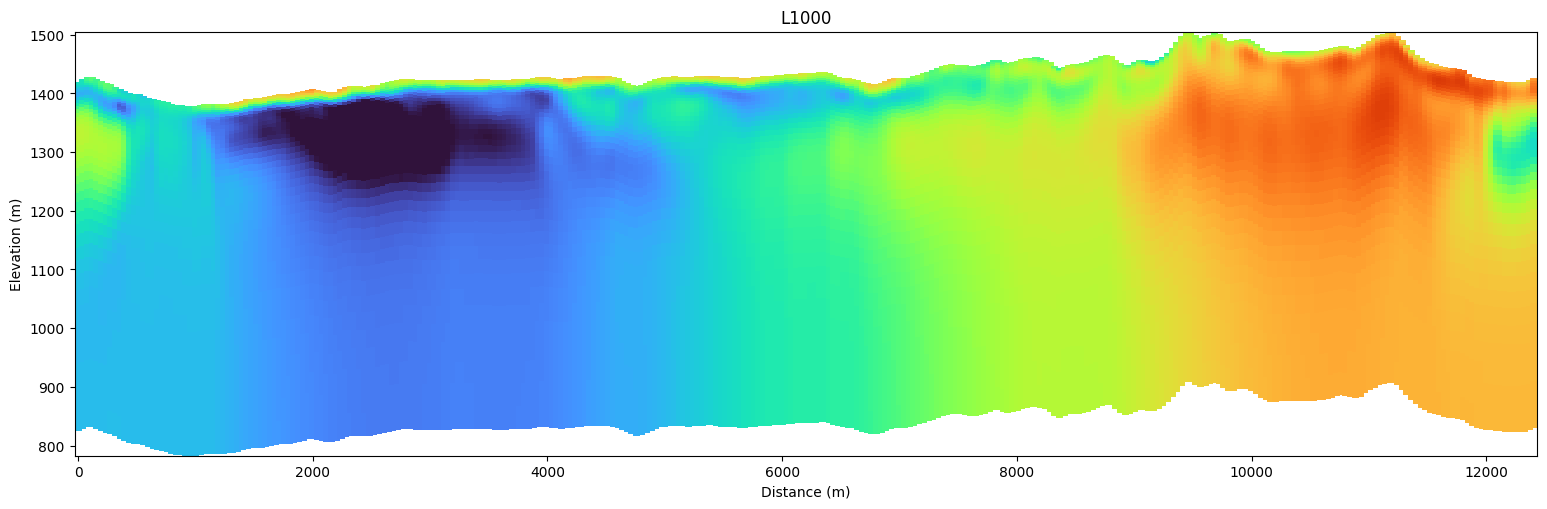

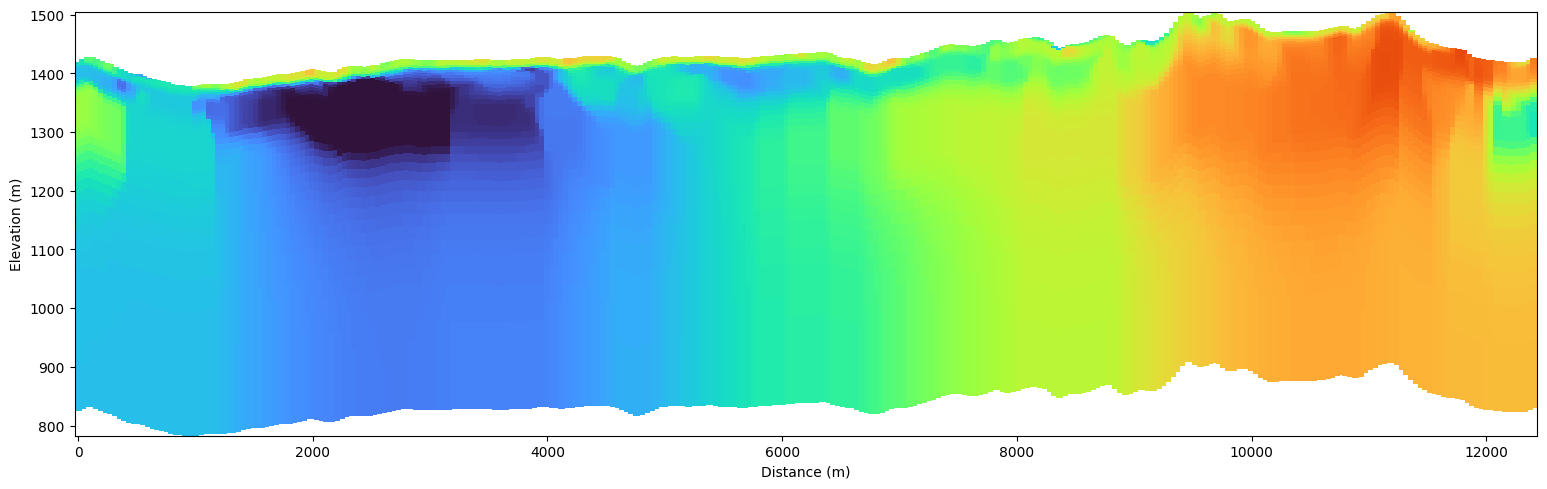

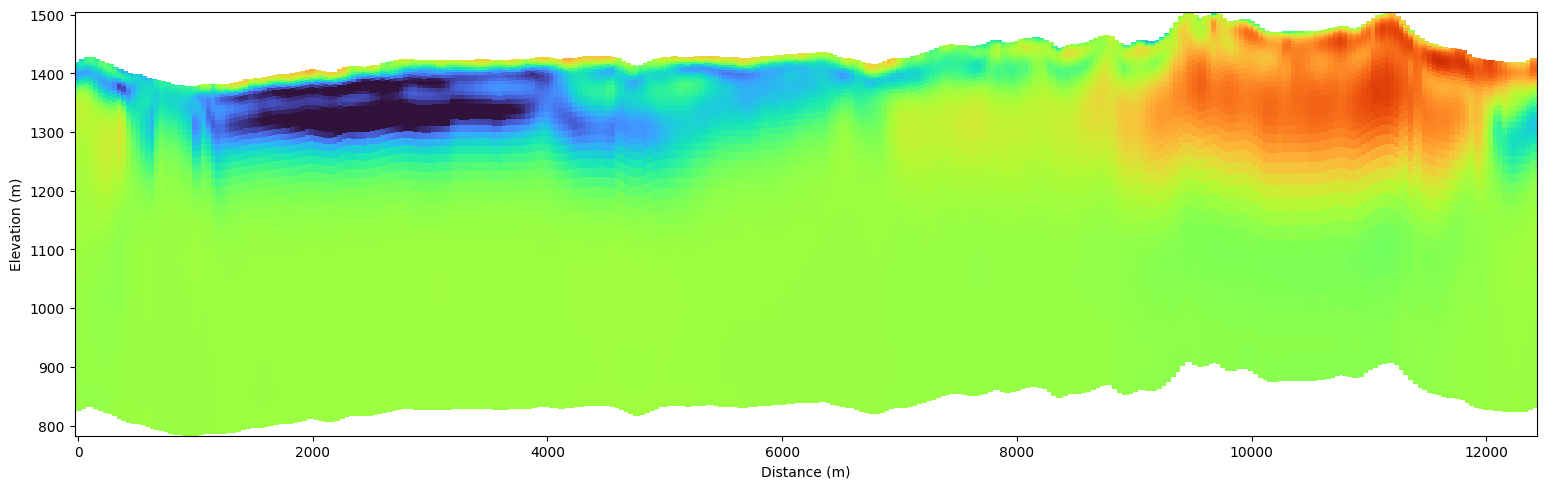

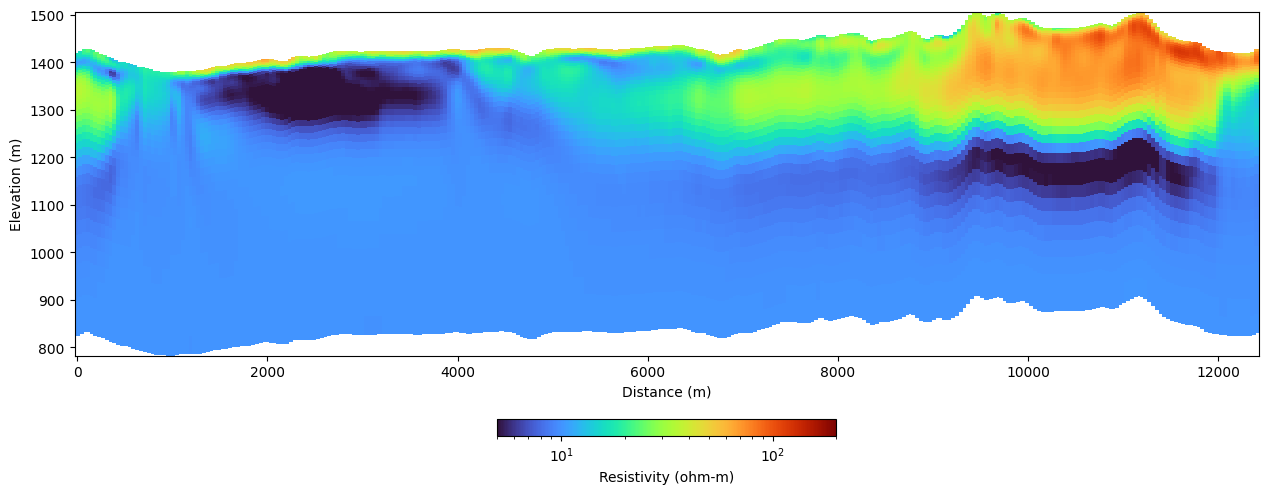

In [54]:
fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0])
# cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
# cb.set_label("Resistivity (ohm-m)")
ax2.set_title(Q.widget.kwargs['line'])

fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0], physical_property=rho_sharp)
# cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
# cb.set_label("Resistivity (ohm-m)")
# ax2.set_title(Q.widget.kwargs['line'])


fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0], physical_property=rho_ref1)
# cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
# cb.set_label("Resistivity (ohm-m)")
# ax2.set_title(Q.widget.kwargs['line'])

fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0], physical_property=rho_ref2)
cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
cb.set_label("Resistivity (ohm-m)")
# ax2.set_title(Q.widget.kwargs['line'])

# Calculate depth of investigation



In [54]:
def get_doi_index(m1, m2, mref1, mref2):
    doi_index = abs((m1-m2) / (mref1-mref2))
    return doi_index
def get_doi_from_doi_index(DOI_INDEX, hz, threshold=0.8, maximum_doi=400):
    mesh_1d = set_mesh_1d(hz)
    depth = mesh_1d.nodes_x[:-1]
    doi = np.zeros(n_sounding)
    for i_sounding in range(n_sounding):
        doi_index_single = DOI_INDEX[:,i_sounding]
        # doi_index_single /= doi_index_single.max()
        for i_layer in range(hz.size-1, -1, -1):
            if (doi_index_single[i_layer]< threshold) & (depth[i_layer]<maximum_doi):
                break
        doi[i_sounding] = depth[i_layer]
    return doi

ref1 = np.log(1/27.)
ref2 = np.log(1/10.)

doi_index = get_doi_index(m_ref1, m_ref2, ref1, ref2)
DOI_INDEX = doi_index.reshape((hz.size, n_sounding), order='F')
doi = get_doi_from_doi_index(DOI_INDEX, hz, threshold=0.8, maximum_doi=250)

doi_filtered = doi.copy()
for lin in model.unique_line:
    ind_line = model.line == lin
    doi_filtered[ind_line] = scipy.signal.medfilt(doi[ind_line], kernel_size=21)

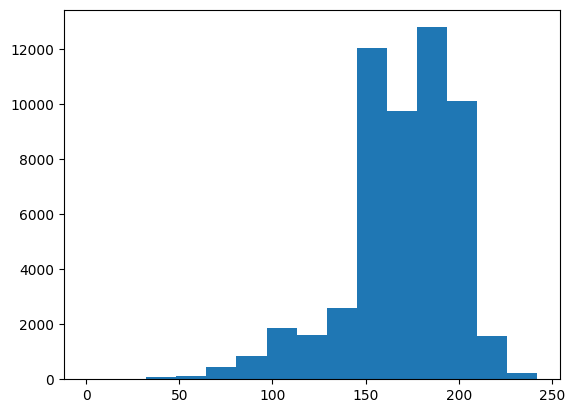

In [55]:
out = plt.hist(doi, bins=15)

In [56]:
line

array([1000, 1000, 1000, ..., 2360, 2360, 2360])

In [57]:
line

array([1000, 1000, 1000, ..., 2360, 2360, 2360])

- L1170
- T2090

In [58]:
Q = interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('L1000', 'L1020', 'L1030', 'L1040', 'L1050', 'L1060'…

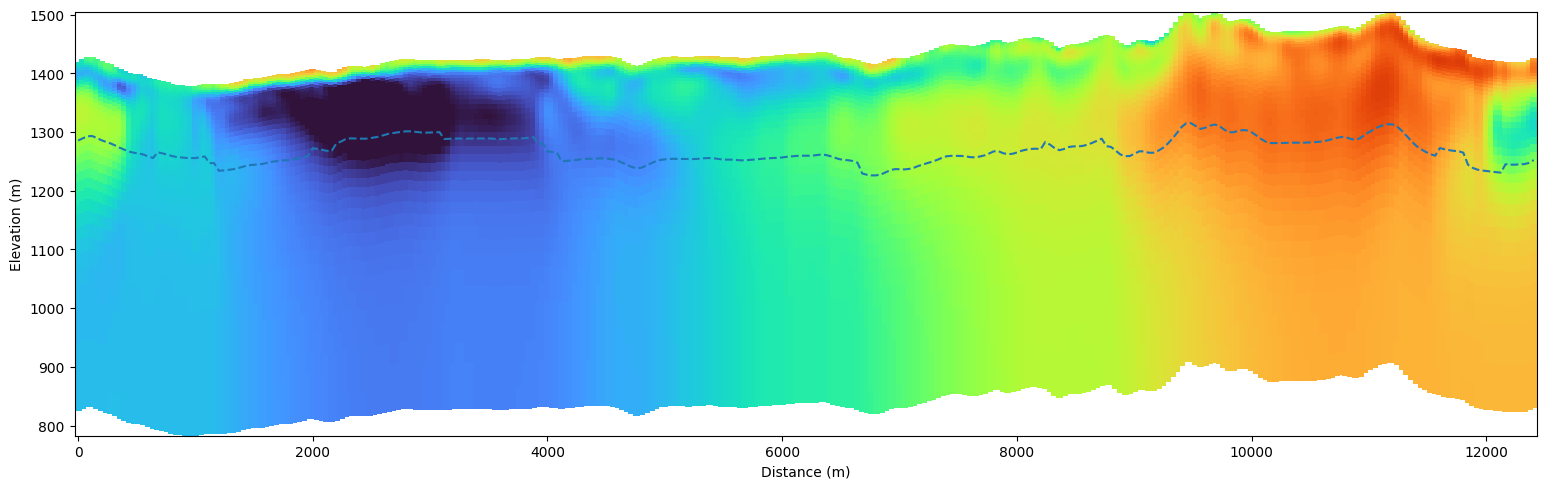

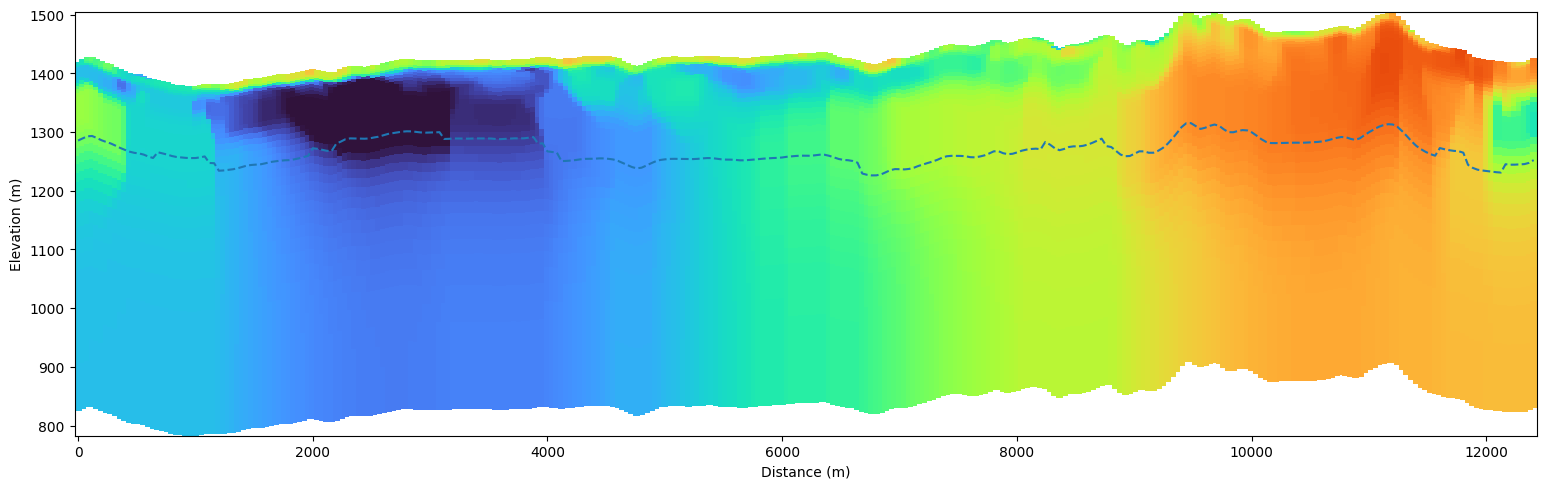

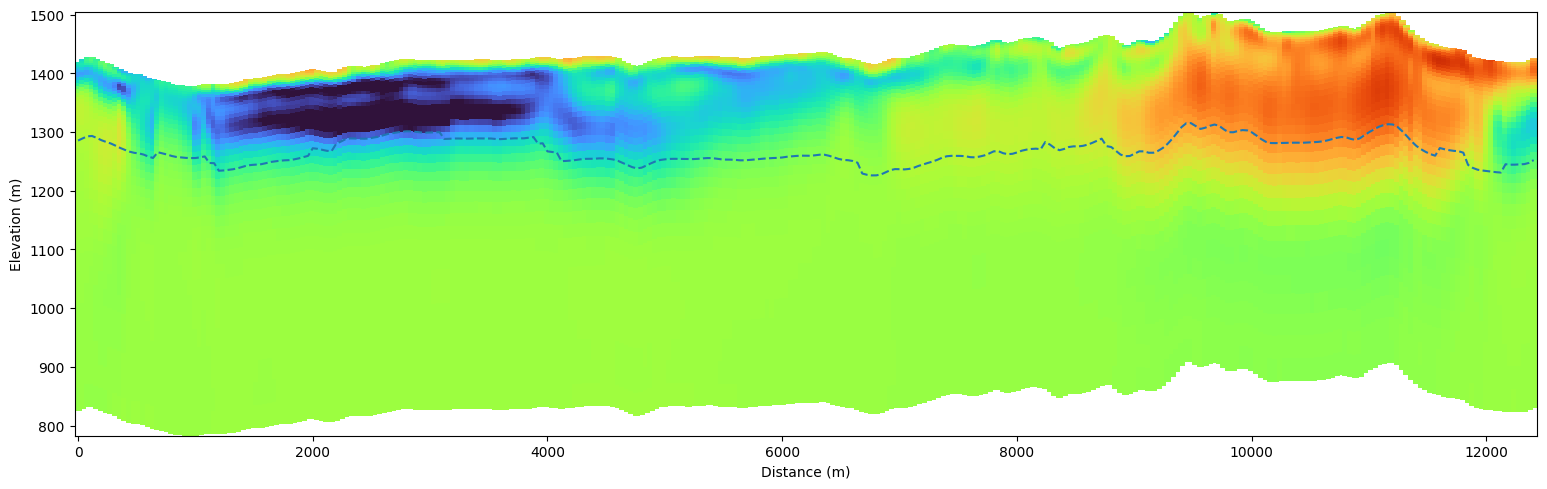

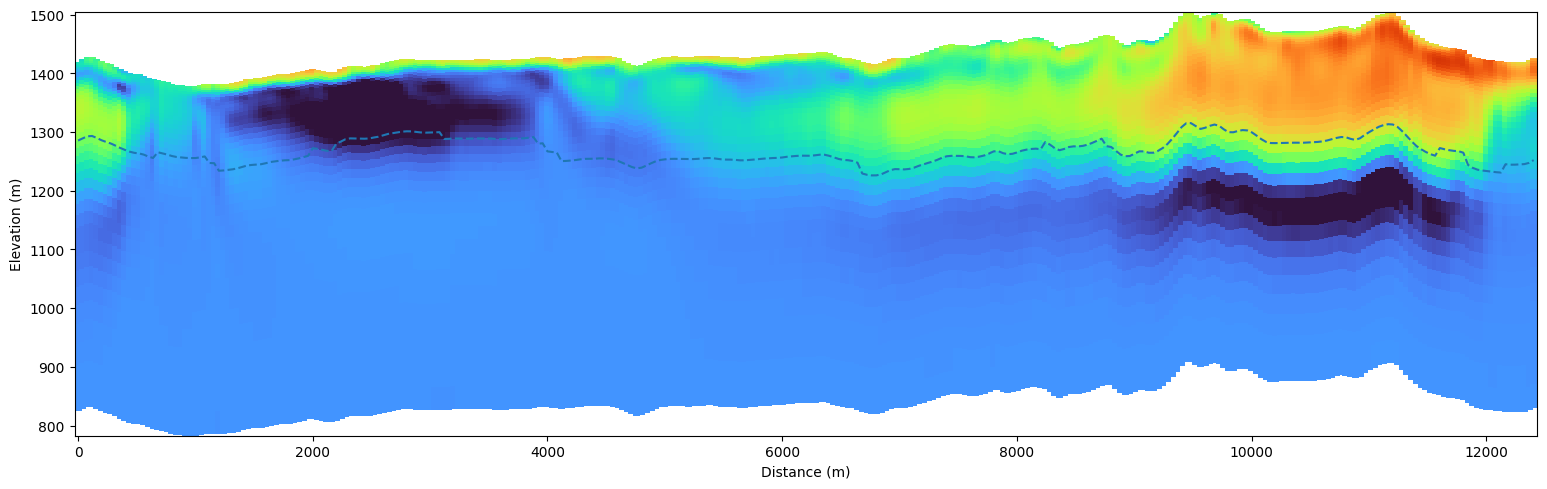

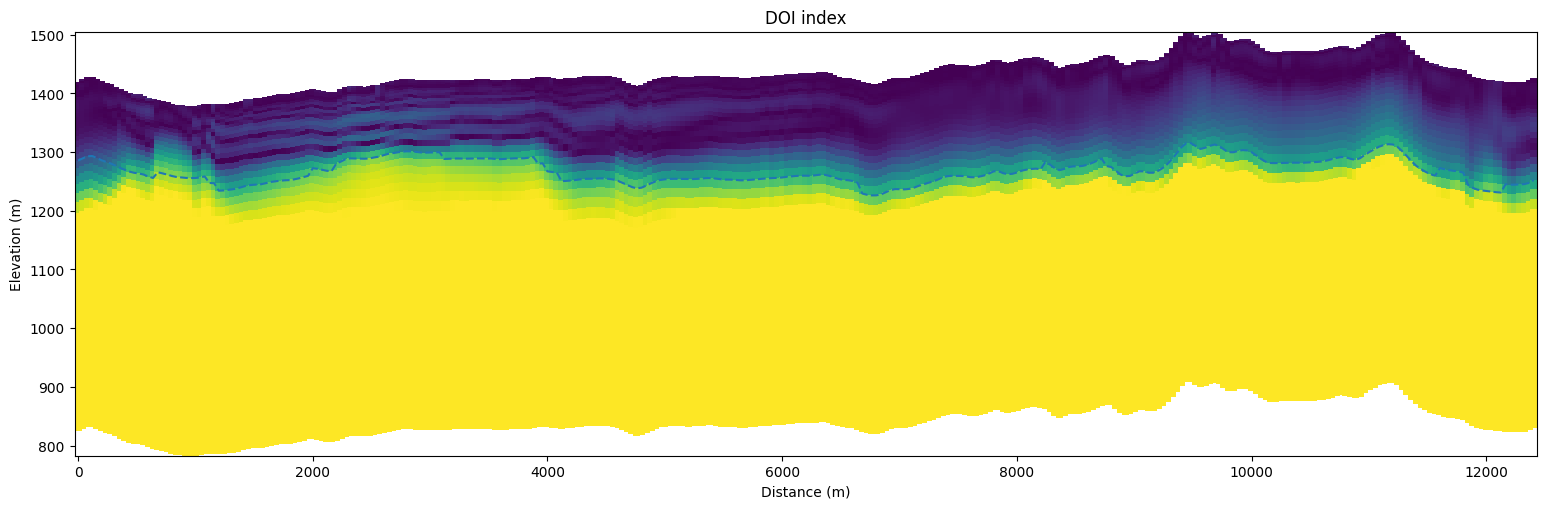

In [59]:
ind_line = line == model.unique_line[np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0]]

fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0])
ax2.plot(model.distance[ind_line], inp.topography[ind_line, 2]-doi_filtered[ind_line], '--')

fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0], physical_property=rho_sharp)
ax2.plot(model.distance[ind_line], inp.topography[ind_line, 2]-doi_filtered[ind_line], '--')

fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0], physical_property=rho_ref1)
ax2.plot(model.distance[ind_line], inp.topography[ind_line, 2]-doi_filtered[ind_line], '--')

# cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
# cb.set_label("Resistivity (ohm-m)")
# ax2.set_title(Q.widget.kwargs['line'])

fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0], physical_property=rho_ref2)
ax2.plot(model.distance[ind_line], inp.topography[ind_line, 2]-doi_filtered[ind_line], '--')

# cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
# cb.set_label("Resistivity (ohm-m)")
# ax2.set_title(Q.widget.kwargs['line'])

fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='viridis', scale='linear', clim=(0, 1), ax=ax2, show_colorbar=False, i_line=np.argwhere(uniq_lines==Q.widget.kwargs['line'] )[0][0], physical_property=doi_index)
ax2.set_title('DOI index')
ax2.plot(model.distance[ind_line], inp.topography[ind_line, 2]- doi_filtered[ind_line], '--')

In [60]:
from scipy.spatial import cKDTree as KDTree
from verde import distance_mask
def inverse_distance_interpolation(
    xy, values, 
    dx=100, dy=100, x_pad=1000, y_pad=1000,
    power=0, epsilon=None, k_nearest_points=20, 
    max_distance=4000.,
):
    """
        Evaluating 2D inverse distance weighting interpolation
        for given (x, y) points and values.
        
        Inverse distance weight, w, can be written as:
            w = 1/(distance+epsilon)**power
        
        Parameters
        ----------
        xy : array_like
            Input array including (x, y) locations; (n_locations, 2)
        values: array_like
            Input array including values defined at (x, y) locations; (n_locations, )
        dx : int 
            Size of the uniform grid in x-direction
        dy : int 
            Size of the uniform grid in y-direction
        x_pad : float 
            Length of padding in x-direction
        y_pad : float 
            Length of padding in y-direction
        power: float
            Exponent used when evaluating inverse distance weight. 
        epsilon: float
            A floor value used when evaluating inverse distance weight. 
        k_nearest_points: int 
            k-nearest-point used when evaluating inverse distance weight.  
        max_distance: float
            A separation distance used to maks grid points away from the (x, y) locations.
        
        Returns        
        -------
        

    """
    xmin, xmax = xy[:,0].min()-x_pad, xy[:,0].max()+x_pad
    ymin, ymax = xy[:,1].min()-y_pad, xy[:,1].max()+y_pad

    nx = int((xmax-xmin) / dx)
    ny = int((ymax-ymin) / dy)
    hx = np.ones(nx) * dx
    hy = np.ones(ny) * dy
    x = np.arange(nx)*dx + xmin
    y = np.arange(ny)*dy + ymin
    X, Y = np.meshgrid(x, y)

    tree = KDTree(xy)

    d, inds_idw = tree.query(np.c_[X.flatten(), Y.flatten()], k=int(k_nearest_points))
    if epsilon is None:
        epsilon = np.min([dx, dy])
    w = 1.0 / ((d+epsilon) ** power)
    values_idw = (np.sum(w * values[inds_idw], axis=1) / np.sum(w, axis=1))
    mask_inds = ~distance_mask(
        (xy[:,0], xy[:,1]), maxdist=max_distance, coordinates=(X.flatten(), Y.flatten())
    )
    values_idw[mask_inds] = np.nan
    values_idw = values_idw.reshape(X.shape)
    return x, y, values_idw

In [61]:
xy = topography[:,:2]

In [62]:
doi_filtered.shape

(54032,)

In [63]:
from matplotlib.colors import LogNorm

In [64]:
import matplotlib
matplotlib.rcParams['font.size'] = 8

In [65]:
i_layer = 3
x, y, values_rho_idw = inverse_distance_interpolation(
    xy, rho_sharp.reshape((n_sounding, n_layer))[:,i_layer], dx=100, dy=100, k_nearest_points=50,
    # x_pad=500, y_pad=500,
    max_distance=2000.,
)

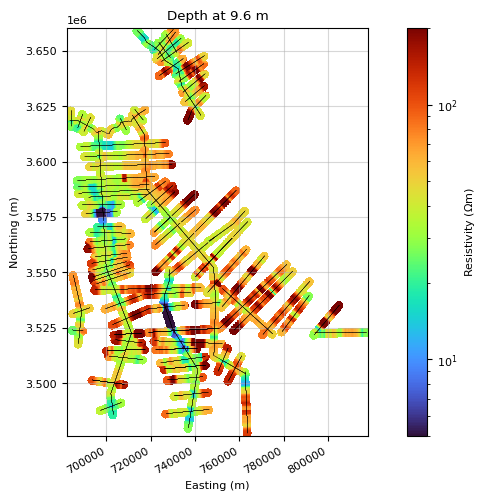

In [66]:
fig, ax = plt.subplots(1,1, figsize=(10, 6))
depth = np.cumsum(np.r_[0., hz])
out = plt.pcolormesh(x, y, values_rho_idw, 
    cmap='turbo', 
    norm=LogNorm(vmin=5, vmax=200)
)
ax.plot(topography[:,0], topography[:,1], 'k,', alpha=0.1)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
cb = plt.colorbar(out)
cb.set_label('Resistivity ($\Omega$m)')
ax.grid(True, alpha=0.5)
ax.set_aspect(1)
ax.set_title("Depth at {:.1f} m".format(depth[i_layer]))
fig.autofmt_xdate()

In [67]:
x, y, values_idw = inverse_distance_interpolation(xy, doi, dx=100, dy=100, k_nearest_points=50, max_distance=2000)

Text(0.5, 1.0, 'Depth of investigation')

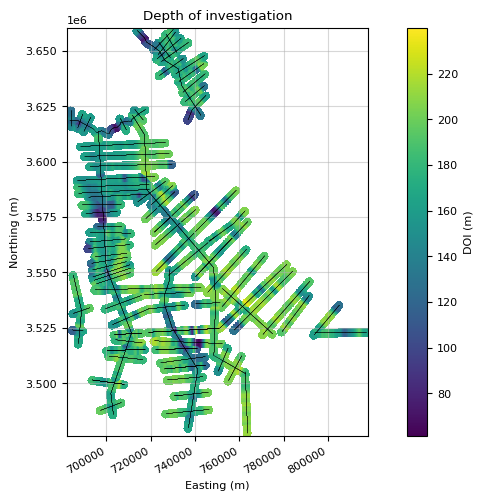

In [68]:
fig, ax = plt.subplots(1,1, figsize=(10, 6))
depth = np.cumsum(np.r_[0., hz])
out = plt.pcolormesh(x, y, values_idw, 
    cmap='viridis'
)
ax.plot(topography[:,0], topography[:,1], 'k,', alpha=0.1)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
cb = plt.colorbar(out)
cb.set_label('DOI (m)')
ax.grid(True, alpha=0.5)
ax.set_aspect(1)
fig.autofmt_xdate()
ax.set_title("Depth of investigation")

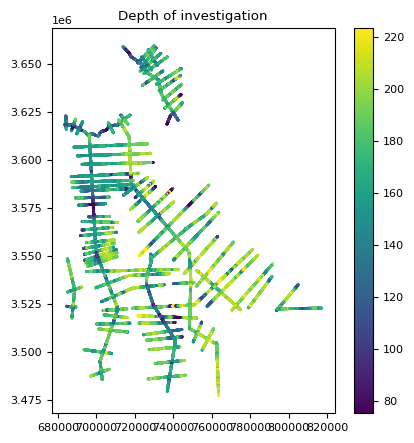

In [69]:
fig, ax1 = plt.subplots(1,1, figsize=(5, 5))
out = ax1.scatter(
    df_data_binned['x'], df_data_binned['y'], c=doi_filtered, 
    s=1,
    vmin=np.percentile(doi, 1),
    vmax=np.percentile(doi, 99)
)
ax1.set_aspect(1)
ax1.set_title("Depth of investigation")
plt.colorbar(out)

In [70]:
# mkdir inversion_results_GL250193_F02

In [71]:
# for i_line in range(len(uniq_lines)):
#     fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
#     out, ax2 = model.plot_section(x_axis='distance', aspect=5, dx=30., alpha=1, cmap='turbo', clim=(5, 200), ax=ax2, show_colorbar=False, i_line=i_line)
#     cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
#     cb.set_label("Resistivity (ohm-m)")
#     line = uniq_lines[i_line]
#     ax2.set_title(line)
#     plt.tight_layout()
#     fig.savefig(f"./inversion_results_{survey_name}/{line}.png", dpi=200)
    

In [72]:
# for line in uniq_lines:
#     fig, axs = plt.subplots(2,1, figsize=(20, 10))
#     ax0, ax = axs

#     # line = uniq_lines[i_line]
#     df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
#     df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]

#     ax0.plot(df_data_binned['x'], df_data_binned['y'], '.')    
#     ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
#     ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
#     ax0.set_aspect(1)
#     scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
#     plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

#     ax_1 = ax.twinx()
#     ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], 'k-', lw=0.5)
#     ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[data_header], 'b--', lw=0.5)
#     ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
#     ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')
#     ax_1.legend()
#     ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
#     plt.tight_layout()
#     fig.savefig(f"./inversion_results_{survey_name}/{line}_data.png", dpi=200)
    

In [73]:
# fig, ax1 = plt.subplots(1,1, figsize=(18, 5))

# ax_1 = ax1.twinx()
# i_line = 5
# line = uniq_lines[i_line]
# df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
# df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]
# ax1.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], 'k-', lw=1)
# out = ax1.semilogy(df_data_binned_line['distance'], df_data_binned_pred_line[data_header], 'b--', lw=1)
# scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
# plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))
# # ax_1.plot(binned['distance'], binned['radarb'], 'r-')
# ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
# ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')

# # ax1.set_xlim(binned['x'].min(), binned['x'].max())


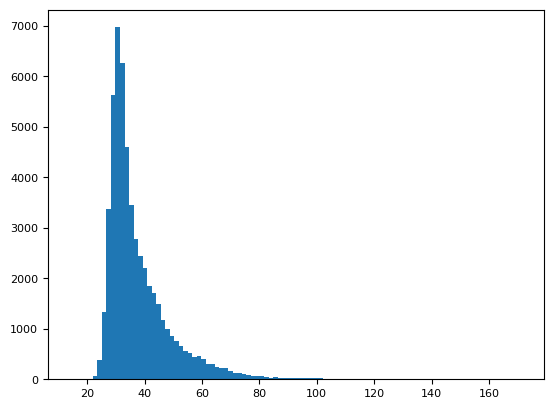

In [74]:
out = plt.hist(df_data_binned['radarb'].values, bins=100)

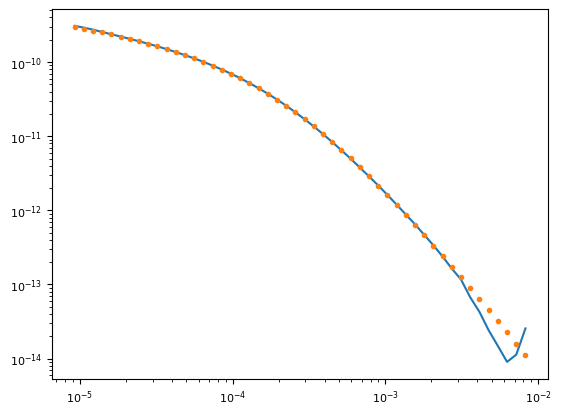

In [75]:
plt.loglog(times, -DOBS[0,:])
plt.loglog(times, -DPRED[0,:], '.')

In [76]:
survey_name = 'bootheel'
rho = 1./np.exp(m)
columns = df_data_binned[['x', 'y', 'DEM', 'PLM']]
record = np.array(np.arange(simulation.n_sounding))
depth = np.r_[0., np.cumsum(hz)]
top = depth[:-1]
bottom = depth[1:]
TOP = np.tile(top, (simulation.n_sounding, 1))
BOTTOM = np.tile(bottom, (simulation.n_sounding, 1))
line_no = df_data_binned['Line'].values
names_top = [f'top_{ii+1}_layer_m'for ii in range(len(hz))]
names_bottom = [f'bottom_{ii+1}_layer_m'for ii in range(len(hz))]
names_rho = [f'rho_{ii+1}_layer_m'for ii in range(len(hz))]
header = ['record', 'line_no', 'utmx', 'utmy', 'elevation', 'plm', 'doi']+ names_top + names_bottom + names_rho
header_dat = ['record', 'line_no', 'utmx', 'utmy', 'elevation', 'plm']+ data_header

df_obs = pd.DataFrame(data=np.c_[record, line_no, columns, -DOBS * 1e12], columns=header_dat)
df_pred = pd.DataFrame(data=np.c_[record, line_no, columns, -DPRED * 1e12], columns=header_dat)

df_obs.to_csv(f"./second_path_results/dobs_{survey_name}.csv", index=False)
df_pred.to_csv(f"./second_path_results/dpred_{survey_name}.csv", index=False)

inv_types = ['smooth', 'sharp', 'ref1', 'ref2']
rhos = [rho_smooth, rho_sharp, rho_ref1, rho_ref2]

for inv_type, rho in zip(inv_types, rhos):
    RHO = rho.reshape((simulation.n_sounding, len(hz)))
    data = np.c_[record, line_no, columns, doi_filtered, TOP, BOTTOM, RHO]
    df = pd.DataFrame(data=data, columns=header)
    df.to_csv(f"./second_path_results/rho_{survey_name}_{inv_type}.csv", index=False)

In [77]:
# !mkdir ./inversion_results_GL250193

In [78]:
survey_name

'bootheel'

In [79]:
# df1 = pd.read_csv("inversion_results/rho_L4010.csv")
# pd.concat([df, df1]).to_csv(f"inversion_resulats/rho_inv_silvercity.csv", index=False)

- 'record': numbering of sounding for each line
- 'line_no': line number
- 'utmx': easting (m)
- 'utmy': northing (m)
- 'elevation': ground elevation
- 'plm': powerline monitor
- 'top_x_layer_m': top depth of the x-th layer
- 'bottom_x_layer_m': bottom of the x-th layer
- 'rho_x_layer_m': resistivity of the x-th layer

In [80]:
from SimPEG import utils
def write_aem_leapfrog_csv(
    hz, Line, topography, properties,
    name_properties=['resistivity'],
    nskip=1, work_dir='./', fname_header=''
):

    n_sounding_all = topography.shape[0]
    stitched_model = Stitched1DModel(
        line=Line[::nskip],
        topography=topography[::nskip,:].copy(),
        time_stamp=np.arange(n_sounding),
        thicknesses=hz[:-1],           
    )
    depth_from = np.zeros((hz.size, stitched_model.n_sounding), order='F')
    depth_to = np.zeros((hz.size, stitched_model.n_sounding), order='F')

    # collar information
    lineid_collar = Line[::nskip]
    wellid_collar = np.arange(lineid_collar.size) + 1

    north_collar = stitched_model.topography[:,1]
    east_collar = stitched_model.topography[:,0]
    depth_max_collar = np.ones_like(wellid_collar) * hz.sum()
    elevation_collar = stitched_model.topography[:,2]

    # interval information

    for ii in range(stitched_model.n_sounding):
        depth_from[:,ii] = stitched_model.mesh_1d.nodes_x[:-1]
        depth_to[:,ii] = stitched_model.mesh_1d.nodes_x[1:]

    lineid = stitched_model.line.repeat(hz.size)
    wellid = wellid_collar.repeat(hz.size)
    east = utils.mkvc(stitched_model.xyz[:,0])
    north = utils.mkvc(stitched_model.xyz[:,1])
    depth_from = utils.mkvc(depth_from[:,:])
    depth_to = utils.mkvc(depth_to[:,:])

    df_collar = pd.DataFrame(data=np.c_[wellid_collar, stitched_model.line, east_collar, north_collar, elevation_collar, depth_max_collar], columns=['wellid', 'Line', 'X', 'Y', 'elevation', 'depth'])
    df_collar.to_csv(work_dir+'collar-{:s}.csv'.format(fname_header), index=False)


    distance_collar = np.zeros_like(wellid_collar)
    azimuth_collar = np.zeros_like(wellid_collar)
    dip_collar = np.ones_like(wellid_collar) * 90.

    df_survey = pd.DataFrame(data=np.c_[wellid_collar, distance_collar, azimuth_collar, dip_collar], columns=['wellid', 'distance', 'azimuth', 'dip'])
    df_survey.to_csv(work_dir+'survey-{:s}.csv'.format(fname_header), index=False)
    data = np.c_[wellid, depth_from, depth_to]
    for ii in range (len(name_properties)):
        data = np.c_[data, properties[:,ii].reshape((n_sounding_all, hz.size))[::nskip, :].flatten()]
    df_interval = pd.DataFrame(
        data=data,
        columns=['wellid', 'from', 'to'] + name_properties
    )
    df_interval.to_csv(work_dir+'interval-{:s}.csv'.format(fname_header), index=False)
    return df_collar, df_survey, df_interval

In [81]:
# line = np.array([int(val.strip('L').strip('T')) for val in df_data_binned['Line'].values])

In [82]:
# write_aem_leapfrog_csv(
#     hz, line, topography, rho.reshape([-1,1]),
#     name_properties=['resistivity'],
#     nskip=3, work_dir=f'./inversion_results_{survey_name}/', fname_header=survey_name
# )

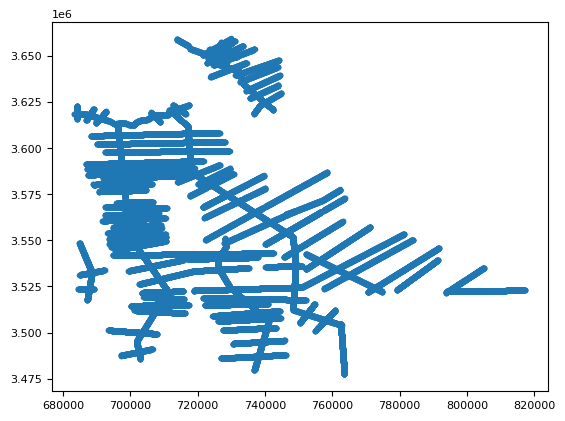

In [83]:

plt.plot(df_data_binned['x'], df_data_binned['y'], '.')

In [84]:
df_data_binned.keys()

Index(['Line', 'distance', 'x', 'y', 'DEM', 'radar', 'radarb', 'PLM', 'SFz[8]',
       'SFz[9]', 'SFz[10]', 'SFz[11]', 'SFz[12]', 'SFz[13]', 'SFz[14]',
       'SFz[15]', 'SFz[16]', 'SFz[17]', 'SFz[18]', 'SFz[19]', 'SFz[20]',
       'SFz[21]', 'SFz[22]', 'SFz[23]', 'SFz[24]', 'SFz[25]', 'SFz[26]',
       'SFz[27]', 'SFz[28]', 'SFz[29]', 'SFz[30]', 'SFz[31]', 'SFz[32]',
       'SFz[33]', 'SFz[34]', 'SFz[35]', 'SFz[36]', 'SFz[37]', 'SFz[38]',
       'SFz[39]', 'SFz[40]', 'SFz[41]', 'SFz[42]', 'SFz[43]', 'SFz[44]',
       'SFz[45]', 'SFz[46]', 'SFz[47]', 'SFz[48]', 'SFz[49]', 'SFz[50]',
       'SFz[51]', 'SFz[52]', 'SFz[53]', 'SFz[54]', 'SFz[55]', 'SFz[56]',
       'SFz[57]'],
      dtype='object')

In [85]:
import geopandas as gpd
from shapely.geometry import LineString
# --- INPUTS ---
name = 'bootheel'
out_shp  = f"{name}_lines.geojson"
crs_epsg = 32613                 # <-- change (e.g., 4326 for lon/lat)

# --- READ ---
df = df_data_binned.copy()

# Required columns
xcol, ycol = "x", "y"

# Optional columns:
# - line_id: to create multiple line features
# - seq: to order points along each line
line_id_col = "Line" if "Line" in df.columns else None
seq_col     = "seq" if "seq" in df.columns else None

# --- BUILD LINES ---
lines = []
attrs = []

if line_id_col:
    grouped = df.groupby(line_id_col)
    for lid, g in grouped:
        coords = list(zip(g[xcol].to_numpy(), g[ycol].to_numpy()))
        if len(coords) < 2:
            continue
        lines.append(LineString(coords))
        attrs.append({line_id_col: lid})

# --- WRITE SHAPEFILE ---
gdf = gpd.GeoDataFrame(attrs, geometry=lines, crs=crs_epsg)
gdf_4326 = gdf.to_crs(4326)
gdf_4326.to_file(out_shp)  # writes .shp/.shx/.dbf/.prj

print(f"Wrote {len(gdf)} line(s) to {out_shp}")

Wrote 114 line(s) to bootheel_lines.geojson


In [ ]:
from csv_to_segy import convert_bootheel_second_path_results

segy_outputs = convert_bootheel_second_path_results("./second_path_results")
print(f"Wrote {len(segy_outputs)} SEG-Y files")
for segy_path, sample_path in segy_outputs[:10]:
    print(f"Wrote {segy_path} and {sample_path}")
if len(segy_outputs) > 10:
    print("...")